# MultiREx - Quickstart
#### Planetary transmission spectra generator
##### [GitHub Repository](https://github.com/D4san/MultiREx-public)
<a target="_blank" href="https://colab.research.google.com/github/D4san/MultiREx-public/blob/main/examples/multirex-quickstart.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

## External dependencies

If you are working in Google Colab use this to install dependencies. 

In [1]:
import sys 
if 'google.colab' in sys.modules:
    !pip install -Uq multirex
    !mkdir resources/

> **NOTE**: After installing you should reset Colab session before importing the package. This is to avoid an unintended behavior of the package `pybtex`.

If you have already reset the Colab session, let's import `MultiREx` and any other package required for this example:

In [2]:
import multirex as mrex
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
# This is for developing purposes
%load_ext autoreload 
%autoreload 2

Numba not installed, using numpy instead
Loading MultiREx version 0.3.1


In [3]:
mrex.Util.get_gases(path='tmp/')

The opacity database already exists at: tmp/opacidades-todas


Once downloaded, the list of available gasses are considerably larger:_

In [4]:
mrex.Util.list_gases()

Available gases in the database:
['O3', 'CO2', 'H2O', 'O2', 'NH3', 'CH4', 'N2', 'C2H6', 'CH3Cl', 'SO2', 'CO', 'HCN', 'DMS', 'NO2']


### Creating components of the system

In [5]:
ggchem_params = {
    'metallicity': 1.0,  # Factor de escala para la metalicidad global ([X/H]) respecto al perfil base.
    'selected_elements': ['C','O','H','N'], # Lista de elementos a incluir en la red química.
    'ratio_elements': ['C'], # Elementos para los cuales se definirán explícitamente las proporciones (e.g., C/O).
    'abundance_profile': 'solar',  # Perfil de abundancia de referencia (e.g., 'solar' para abundancias solares).
    'ratios_to_O': [0.54],  # Proporciones de los 'ratio_elements' respecto al Oxígeno. Aquí, C/O = 0.54.
    'equilibrium_condensation': True, # Booleano para activar o desactivar la condensación en equilibrio.
    # 'output_gases': ['H2O', 'CO', 'CO2', 'CH4', 'NH3', 'HCN', 'Na', 'K', 'TiO', 'VO'] # Opcional: lista para forzar la salida de gases específicos.
}



In [6]:
system = mrex.System(
    star=mrex.Star(
        temperature=5777,
        radius=1,
        mass=1
    ),
    planet=mrex.Planet(
        radius=1,
        mass=1,
        atmosphere=mrex.Atmosphere(
            temperature=290, # in K
            base_pressure=1e5, # in Pa
            top_pressure=1, # in Pa
            chemistry_type='ggchem', # Especifica 'ggchem' para utilizar el modelo químico GGChem.
            ggchem_params=ggchem_params # Pasa los parámetros de GGChem definidos anteriormente.
        )
    ),
    sma=1
)

### The transmission model

Once we have a system we can create the transmission model:

In [7]:
system.make_tm()

### Generating a transmission spectrum

In order to create and manipulate a transmission spectrum, we need first to genereta a wave number grid:

In [8]:
wns = mrex.Physics.wavenumber_grid(wl_min=0.6,wl_max=10,resolution=1000)

The corresponding wavelength grid is:

In [9]:
wls = np.sort(1e4/wns)
wls[:10],wls[-10:]

(array([0.6       , 0.60169212, 0.60338901, 0.60509068, 0.60679716,
        0.60850844, 0.61022456, 0.61194551, 0.61367132, 0.61540199]),
 array([ 9.74972472,  9.77722085,  9.80479454,  9.83244598,  9.86017541,
         9.88798304,  9.91586909,  9.94383379,  9.97187735, 10.        ]))

Let's generate the transmission spectrum:

In [10]:
wns,spectrum = system.generate_spectrum(wns)
wls = 1e4/wns

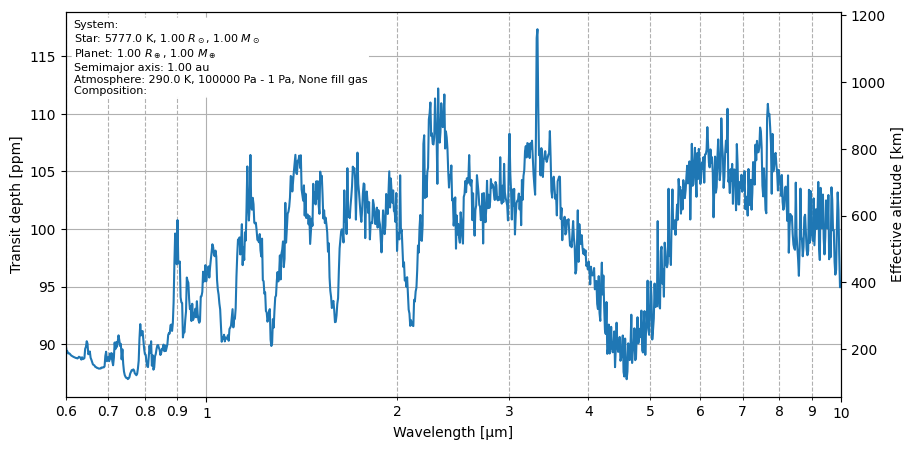

In [11]:
fig, ax = system.plot_spectrum(wns,xscale='log')

### Studying spectral contributions

In order to understand a given spectrum you can also calculate all the individual contributions:

In [12]:
wns, contributions = system.generate_contributions(wns)

Contributions are also calculated as transit depths. Contributions are given as a dictionary with two keys: *Absorption* and *Rayleigh* scattering. 

We have devised a special method to plot all contributions at once:

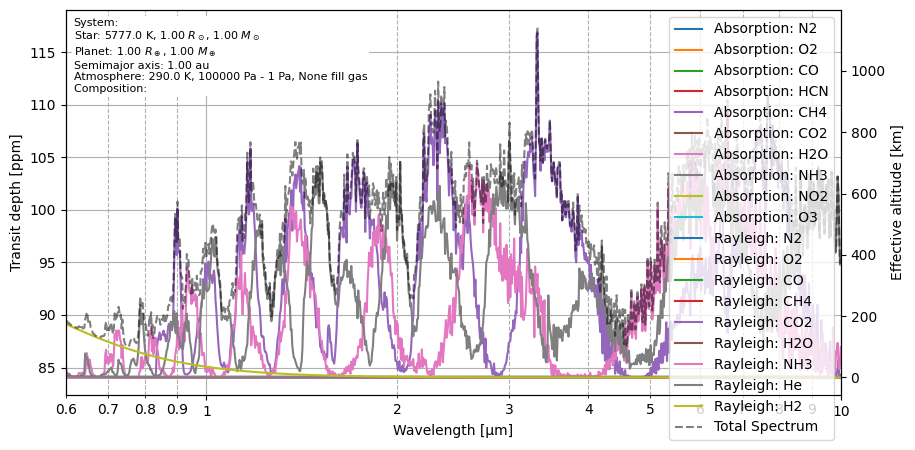

In [13]:
fig, ax = system.plot_contributions(wns,xscale='log')

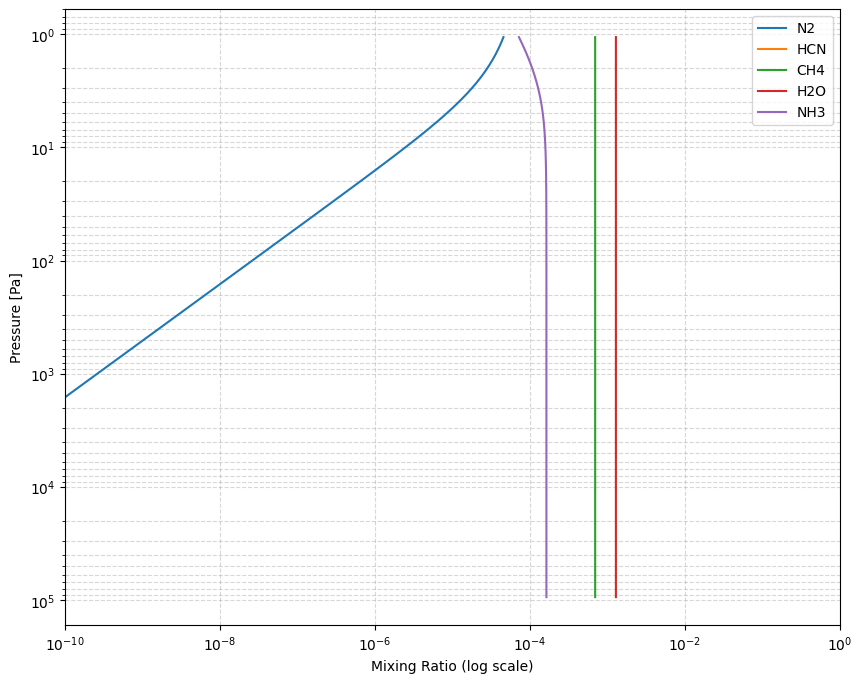

(<Figure size 1000x800 with 1 Axes>,
 <Axes: xlabel='Mixing Ratio (log scale)', ylabel='Pressure [Pa]'>)

In [14]:
system.plot_mixing_ratio(min_mix=1e-10,
 list_gases=['CH4','HCN',"H2O", "NH3","N2"]
 )